In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
from collections import Counter

In [11]:
df = pd.read_csv("data_with_id.csv")

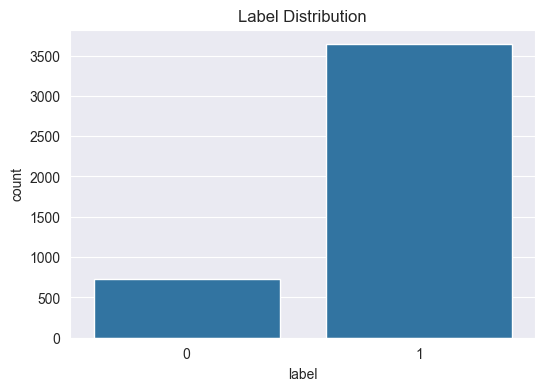

label
1    3638
0     734
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label")
plt.title("Label Distribution")
plt.show()

print(df["label"].value_counts())

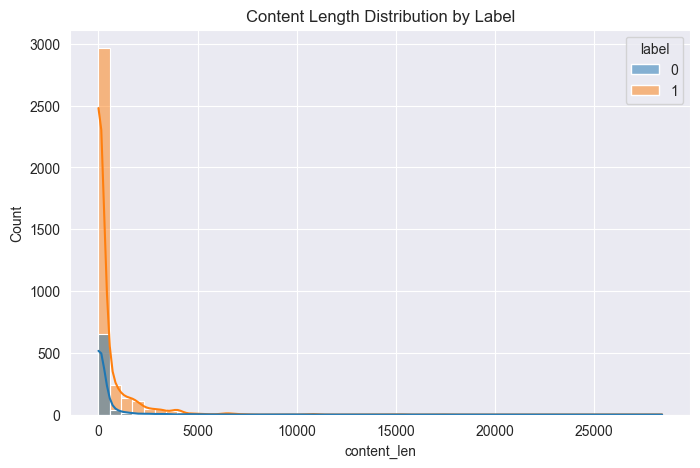

In [5]:
df["content_len"] = df["content"].fillna("").astype(str).apply(len)
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="content_len", hue="label", bins=50, kde=True)
plt.title("Content Length Distribution by Label")
plt.show()

In [12]:
with open("split.json", "r", encoding="utf-8") as f:
    splits = json.load(f)
    train_df = df[df["id"].isin(splits["train"])].copy()
    val_df   = df[df["id"].isin(splits["val"])].copy()
    test_df  = df[df["id"].isin(splits["test"])].copy()

In [13]:
print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

Train size: 3060
Val size: 656
Test size: 656


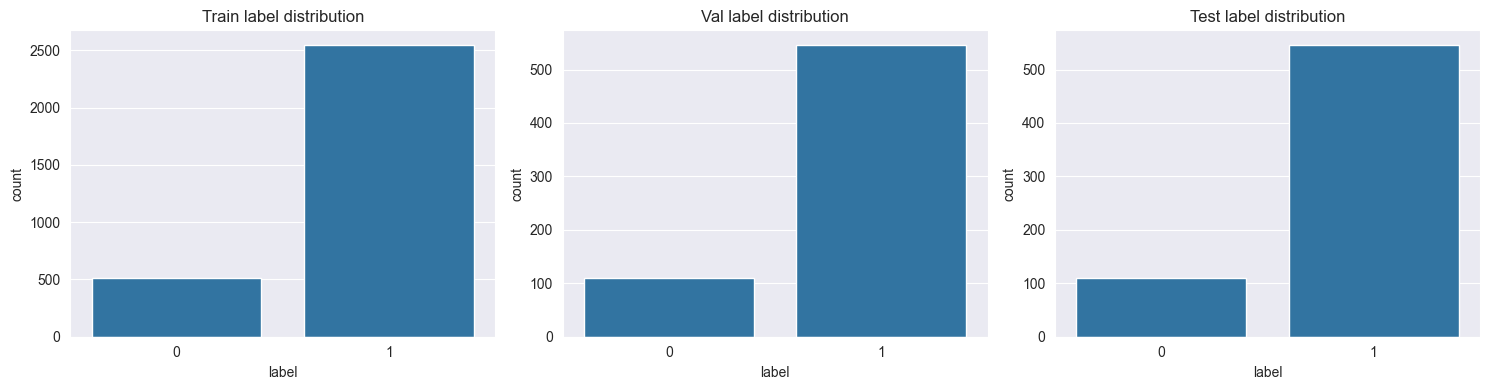

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.countplot(data=train_df, x="label", ax=axes[0])
axes[0].set_title("Train label distribution")

sns.countplot(data=val_df, x="label", ax=axes[1])
axes[1].set_title("Val label distribution")

sns.countplot(data=test_df, x="label", ax=axes[2])
axes[2].set_title("Test label distribution")

plt.tight_layout()
plt.show()

In [15]:
for d in [train_df, val_df, test_df]:
    d["content_len"] = d["content"].fillna("").astype(str).apply(len)

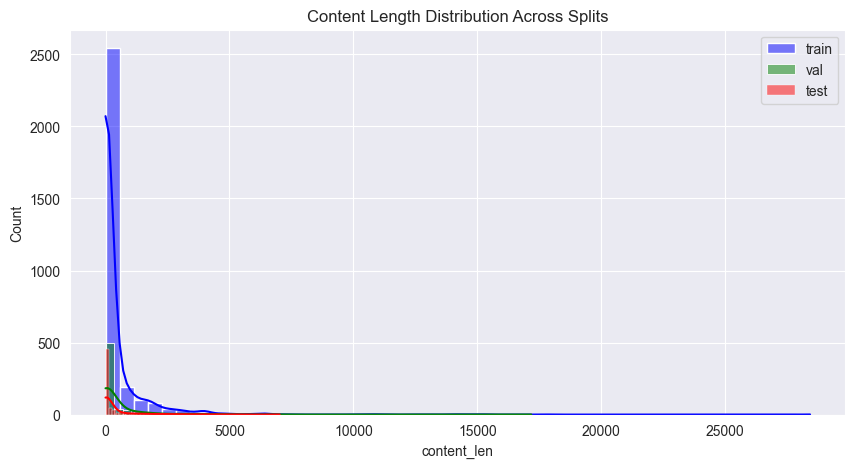

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(train_df["content_len"], label="train", color="blue", kde=True, bins=50)
sns.histplot(val_df["content_len"], label="val", color="green", kde=True, bins=50)
sns.histplot(test_df["content_len"], label="test", color="red", kde=True, bins=50)

plt.legend()
plt.title("Content Length Distribution Across Splits")
plt.show()

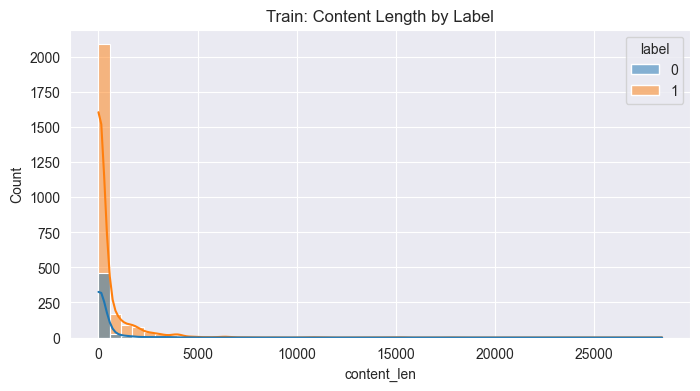

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(data=train_df, x="content_len", hue="label", bins=50, kde=True)
plt.title("Train: Content Length by Label")
plt.show()

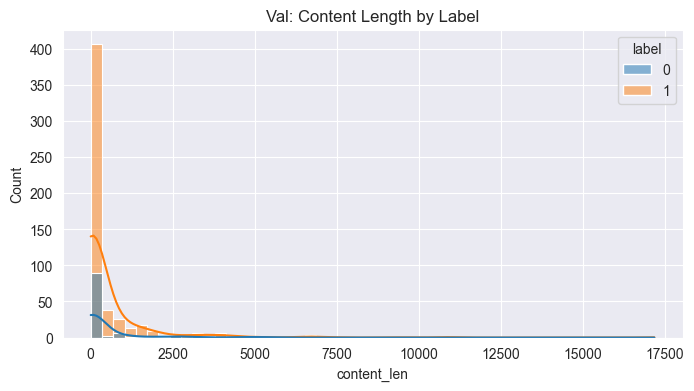

In [18]:
plt.figure(figsize=(8,4))
sns.histplot(data=val_df, x="content_len", hue="label", bins=50, kde=True)
plt.title("Val: Content Length by Label")
plt.show()

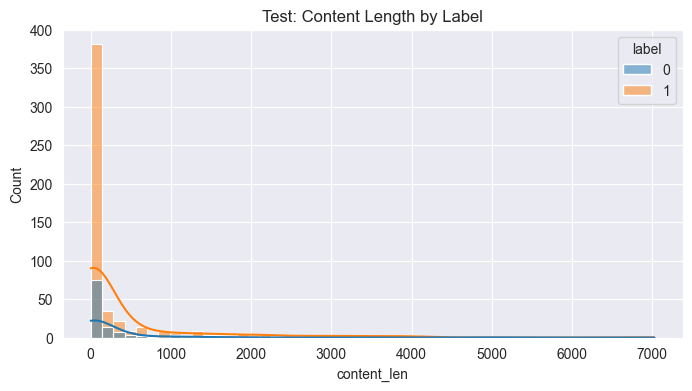

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(data=test_df, x="content_len", hue="label", bins=50, kde=True)
plt.title("Test: Content Length by Label")
plt.show()

In [20]:
def stats(name, d):
    print(f"\n=== {name} ===")
    print(d.groupby("label")["content_len"].describe())

stats("TRAIN", train_df)
stats("VAL", val_df)
stats("TEST", test_df)


=== TRAIN ===
        count        mean          std  min  25%  50%    75%      max
label                                                                
0       514.0  296.040856  1006.485006  0.0  0.0  0.0  201.0  14119.0
1      2546.0  433.613119  1314.149542  0.0  0.0  2.0  260.0  28424.0

=== VAL ===
       count        mean          std  min  25%  50%    75%      max
label                                                               
0      110.0  411.281818  1001.957938  0.0  0.0  0.0  203.5   5349.0
1      546.0  528.135531  1454.094976  0.0  0.0  6.0  367.0  17178.0

=== TEST ===
       count        mean         std  min  25%  50%    75%     max
label                                                             
0      110.0  210.881818  563.252021  0.0  0.0  0.0  208.5  4908.0
1      546.0  397.534799  911.490587  0.0  0.0  2.0  261.0  7028.0


In [28]:
!pip install wordcloud underthesea

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/7.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/7.3 MB 1.8 MB/s eta 0:00:04
   ------- -------------------------------- 1.3/7.3 MB 2.1 MB/s eta 0:00:03
   ---------- ----------------------------- 1.8/7.3 MB 2.2 MB/s eta 0:00:03
   ------------ --------------------------- 2.4/7.3 MB 2.4 MB/s eta 0:00:03
   --------------- ------------------------ 2.9/7.3 MB 2.4 MB/s eta 0:00:02
   ------------------ --------------------- 3.4/7.3 MB 2.4 MB/s eta 0:00:02
   --------------------- ------------------ 3.9/7.3 MB 2.4 MB/s eta 0:00:02
   ------------------------ --------------- 4.5/7.3 MB 2.4 MB/s eta 0:00:02
   --------------------------- ------------ 5.0/7.3 MB 2.4 MB/s eta 0:00:01
   ---------------------------- ----------- 5.2/7.3 MB 2.4 MB/s eta 0:00:01
   --------------------------


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Đã tải thành công 1949 stopwords từ stopwords.txt
--- ĐANG PHÂN TÍCH ĐỘ DÀI TIÊU ĐỀ ---


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24524\2959605015.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='char_count', ax=axes[0], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24524\2959605015.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='word_count', ax=axes[1], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24524\2959605015.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='label', y='exclamation_count', ax=axes[2], palette='Set2')


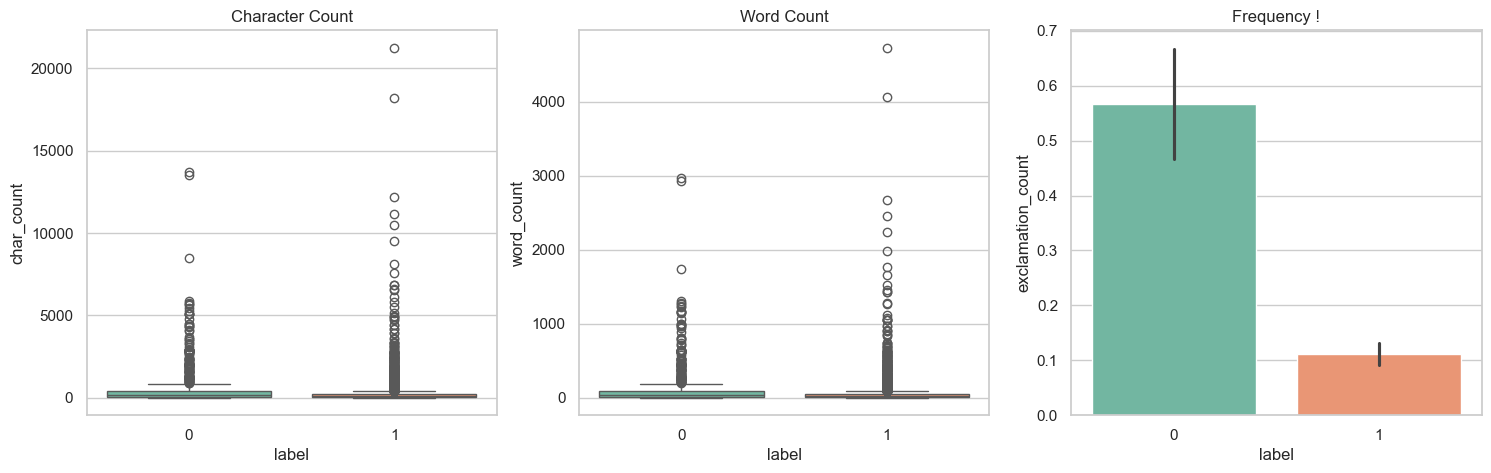

--- ĐANG TẠO WORD FREQUENCY ---


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24524\2959605015.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=list(common_words.keys()), x=list(common_words.values()), ax=ax, palette='Reds_r' if 'Fake' in title else 'Blues_r')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24524\2959605015.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=list(common_words.keys()), x=list(common_words.values()), ax=ax, palette='Reds_r' if 'Fake' in title else 'Blues_r')


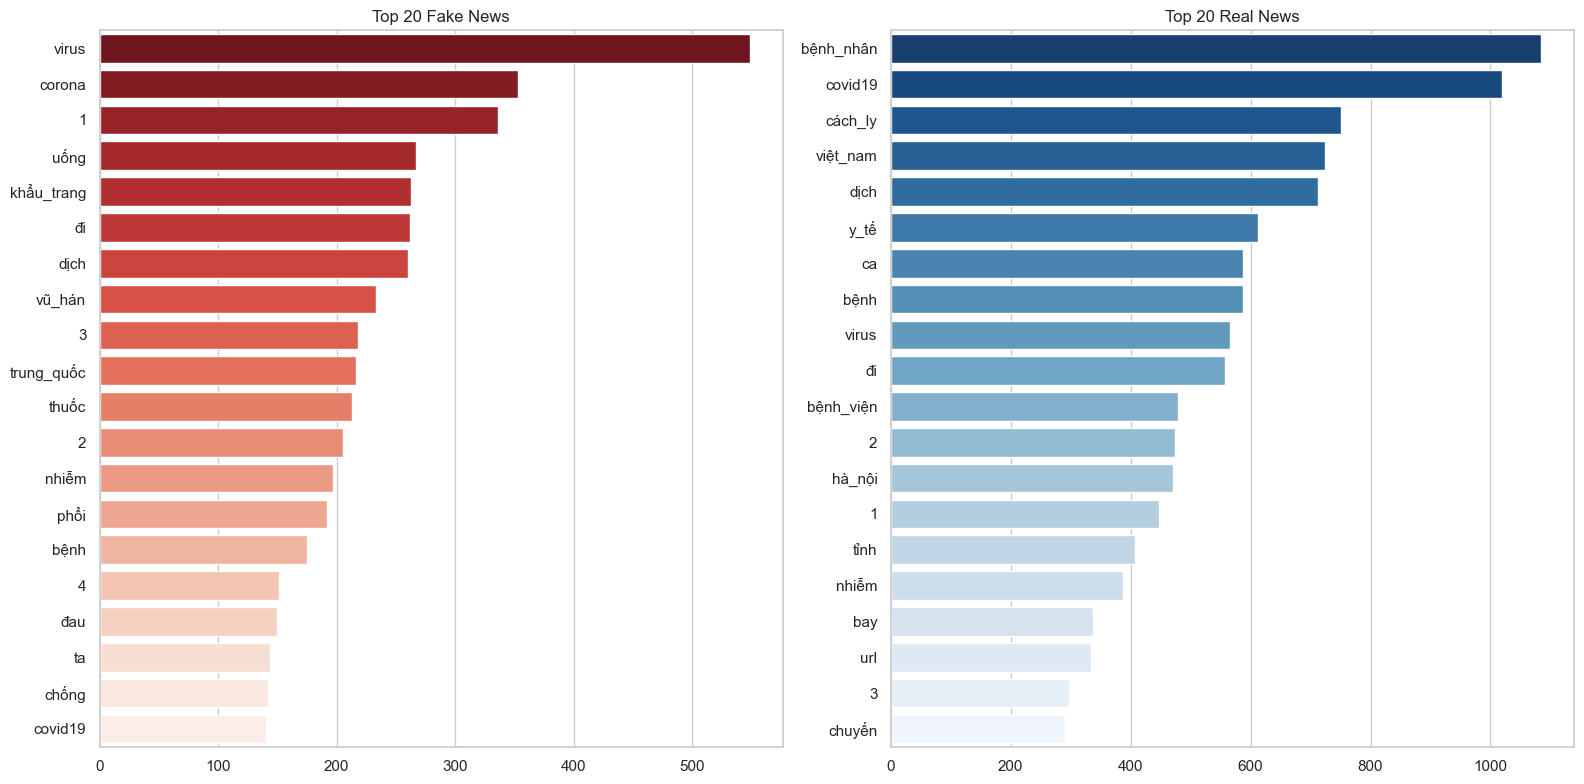

--- ĐANG TẠO WORDCLOUD ---


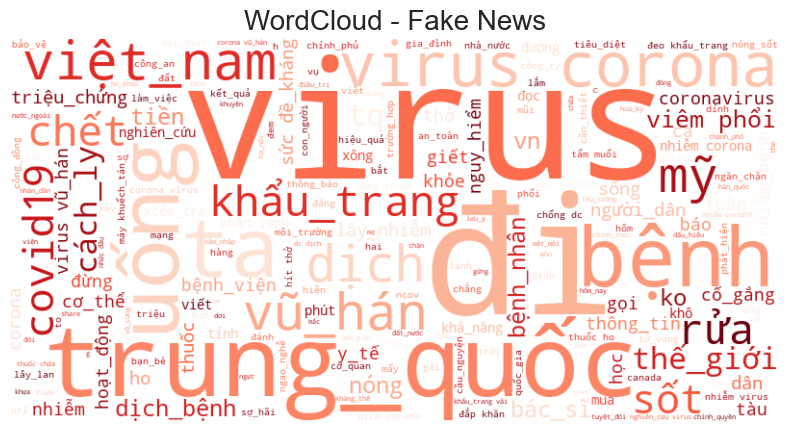

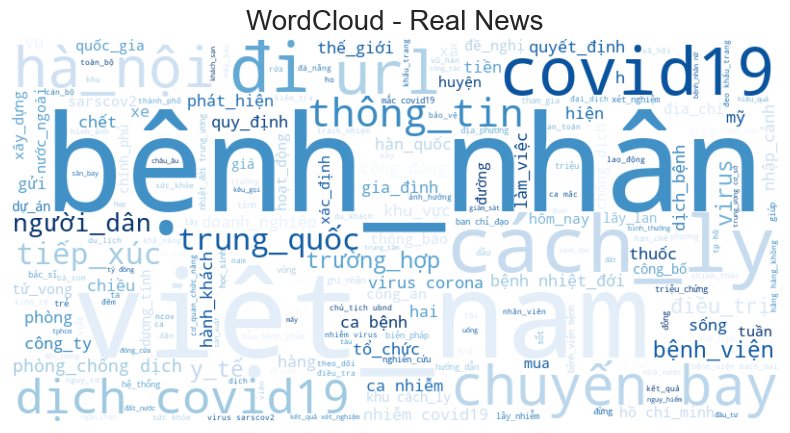

--- ĐANG PHÂN TÍCH VÀ VẼ N-GRAM ---


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24524\2959605015.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Ngram', data=df_ngram, palette=color)


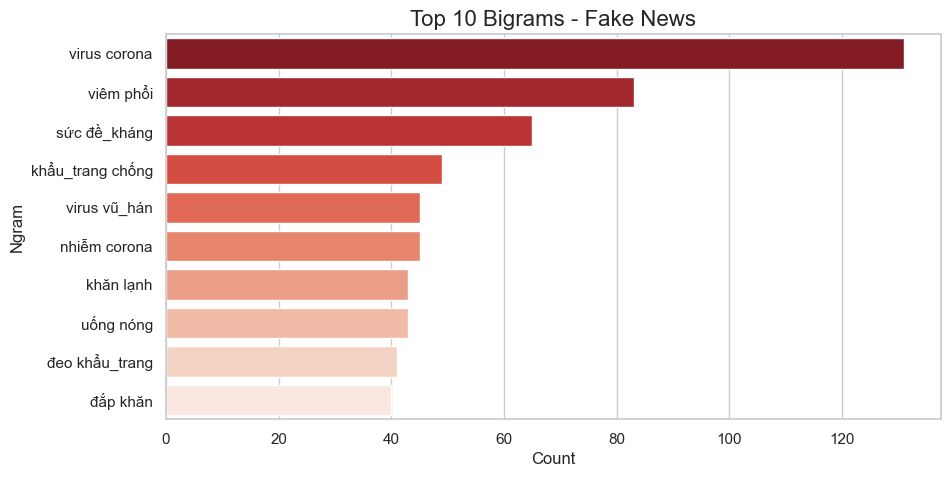

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24524\2959605015.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Ngram', data=df_ngram, palette=color)


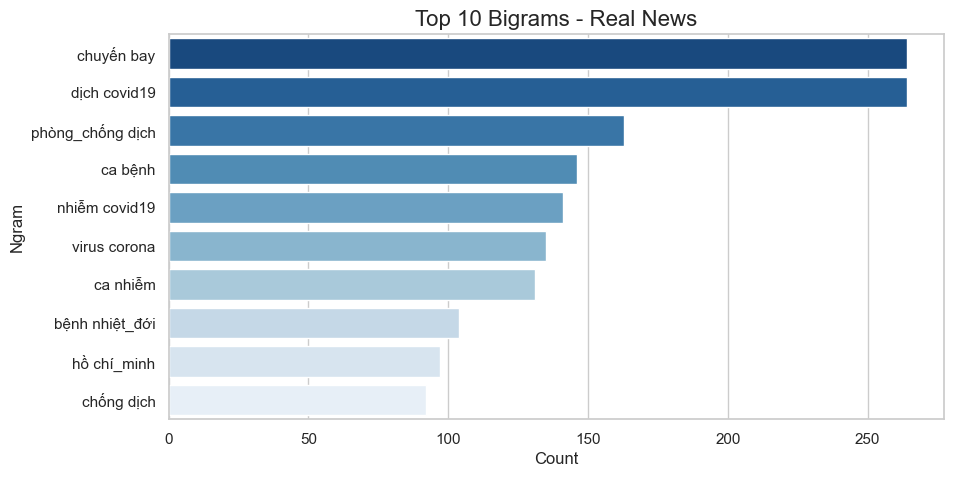

--- ĐANG TỪ TÍNH (POS) & NGỮ NGHĨA ---


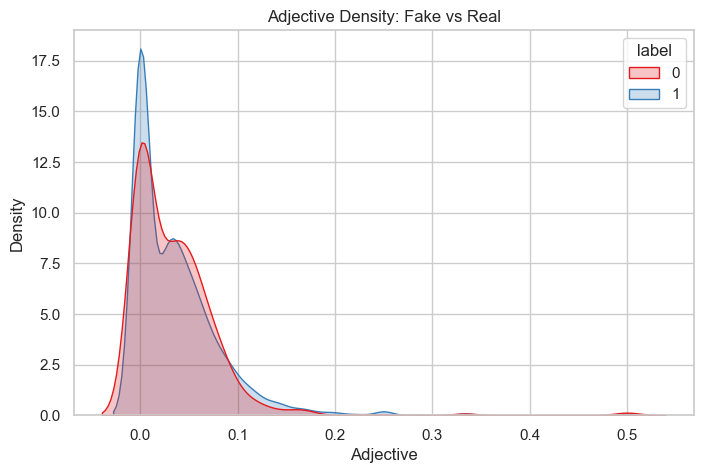

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from underthesea import word_tokenize, pos_tag

# Thiết lập style
sns.set_theme(style="whitegrid")

# ==========================================
# 0. TẢI STOPWORDS TỪ FILE TEXT
# ==========================================
stopwords_vn = []
if os.path.exists('stopwords.txt'):
    with open('stopwords.txt', 'r', encoding='utf-8') as f:
        # Xóa khoảng trắng thừa và thay dấu cách bằng dấu '_' để khớp với underthesea
        stopwords_vn = [line.strip().replace(' ', '_') for line in f.readlines() if line.strip()]
    print(f"Đã tải thành công {len(stopwords_vn)} stopwords từ stopwords.txt")
else:
    print("⚠️ Không tìm thấy file stopwords.txt, sẽ phân tích mà không dùng stopwords.")

# Đọc dữ liệu (Thay bằng file của bạn)
# df = pd.read_csv('vietnamese_news.csv')

# ==========================================
# 1. PREPROCESSING: Hàm làm sạch văn bản cơ bản
# ==========================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text) # Xóa dấu câu
    return text

# Dùng underthesea để tách từ tiếng Việt
def tokenize_vietnamese(text):
    return word_tokenize(text, format="text")

# ==========================================
# 2. TITLE LENGTH ANALYSIS (Độ dài tiêu đề)
# ==========================================
print("--- ĐANG PHÂN TÍCH ĐỘ DÀI TIÊU ĐỀ ---")
df['char_count'] = df['title'].apply(lambda x: len(str(x)))
df['word_count'] = df['title'].apply(lambda x: len(str(x).split()))
df['exclamation_count'] = df['title'].apply(lambda x: str(x).count('!'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x='label', y='char_count', ax=axes[0], palette='Set2')
axes[0].set_title('Character Count')

sns.boxplot(data=df, x='label', y='word_count', ax=axes[1], palette='Set2')
axes[1].set_title('Word Count')

sns.barplot(data=df, x='label', y='exclamation_count', ax=axes[2], palette='Set2')
axes[2].set_title('Frequency !')
plt.show()

# ==========================================
# 3. EDA — WORD FREQUENCY (Tần suất từ)
# ==========================================
print("--- ĐANG TẠO WORD FREQUENCY ---")
df['clean_title'] = df['title'].apply(clean_text).apply(tokenize_vietnamese)

fake_titles = ' '.join(df[df['label'] == 0]['clean_title'])
real_titles = ' '.join(df[df['label'] == 1]['clean_title'])

def plot_top_words(text, title, ax, top_n=20):
    words = text.split()
    # Lọc bỏ stopwords
    words = [w for w in words if w not in stopwords_vn]
    
    counter = Counter(words)
    common_words = dict(counter.most_common(top_n))
    
    if common_words:
        sns.barplot(y=list(common_words.keys()), x=list(common_words.values()), ax=ax, palette='Reds_r' if 'Fake' in title else 'Blues_r')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_top_words(fake_titles, 'Top 20 Fake News', axes[0])
plot_top_words(real_titles, 'Top 20 Real News', axes[1])
plt.tight_layout()
plt.show()

# ==========================================
# 4. EDA — WORDCLOUD (Đám mây từ vựng)
# ==========================================
print("--- ĐANG TẠO WORDCLOUD ---")
def generate_wordcloud(text, title, colormap):
    if not text.strip():
        return
    # Truyền tập stopwords_vn vào WordCloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                          colormap=colormap, stopwords=set(stopwords_vn)).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

generate_wordcloud(fake_titles, 'WordCloud - Fake News', 'Reds')
generate_wordcloud(real_titles, 'WordCloud - Real News', 'Blues')

# ==========================================
# 5. EDA — N-GRAM ANALYSIS (Bigram & Trigram)
# ==========================================
print("--- ĐANG PHÂN TÍCH VÀ VẼ N-GRAM ---")
def get_top_ngrams(corpus, n=10, ngram_range=(2,2)):
    # Đưa stopwords_vn vào CountVectorizer
    vec = CountVectorizer(ngram_range=ngram_range, stop_words=stopwords_vn if stopwords_vn else None).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

def plot_ngrams(ngram_data, title, color):
    if not ngram_data:
        return
    df_ngram = pd.DataFrame(ngram_data, columns=['Ngram', 'Count'])
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Count', y='Ngram', data=df_ngram, palette=color)
    plt.title(title, fontsize=16)
    plt.show()

# Lấy dữ liệu và vẽ Bigrams (Cụm 2 từ)
fake_bigrams = get_top_ngrams(df[df['label'] == 0]['clean_title'], n=10, ngram_range=(2,2))
plot_ngrams(fake_bigrams, 'Top 10 Bigrams - Fake News', 'Reds_r')

real_bigrams = get_top_ngrams(df[df['label'] == 1]['clean_title'], n=10, ngram_range=(2,2))
plot_ngrams(real_bigrams, 'Top 10 Bigrams - Real News', 'Blues_r')

# ==========================================
# 6 & 7. EDA — POS & LINGUISTIC 
# ==========================================
print("--- ĐANG TỪ TÍNH (POS) & NGỮ NGHĨA ---")
def count_pos(text):
    try:
        tags = pos_tag(text)
        adj_count = sum(1 for word, pos in tags if pos == 'A') # Tính từ
        adv_count = sum(1 for word, pos in tags if pos == 'R') # Trạng từ
        return pd.Series({'adj_count': adj_count, 'adv_count': adv_count})
    except:
        return pd.Series({'adj_count': 0, 'adv_count': 0})

df[['adj_count', 'adv_count']] = df['title'].apply(count_pos)
df['adj_density'] = df['adj_count'] / df['word_count']

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='adj_density', hue='label', fill=True, common_norm=False, palette='Set1')
plt.title('Adjective Density: Fake vs Real')
plt.xlabel('Adjective')
plt.show()

PHẦN 1: FEATURE ENGINEERING (READABILITY & STYLE)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24524\2026399314.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='label', y='exclamation_count', ax=axes[0,0], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24524\2026399314.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='label', y='all_caps_count', ax=axes[0,1], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24524\2026399314.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='label', y='question_count', ax=axes[1,1], palet

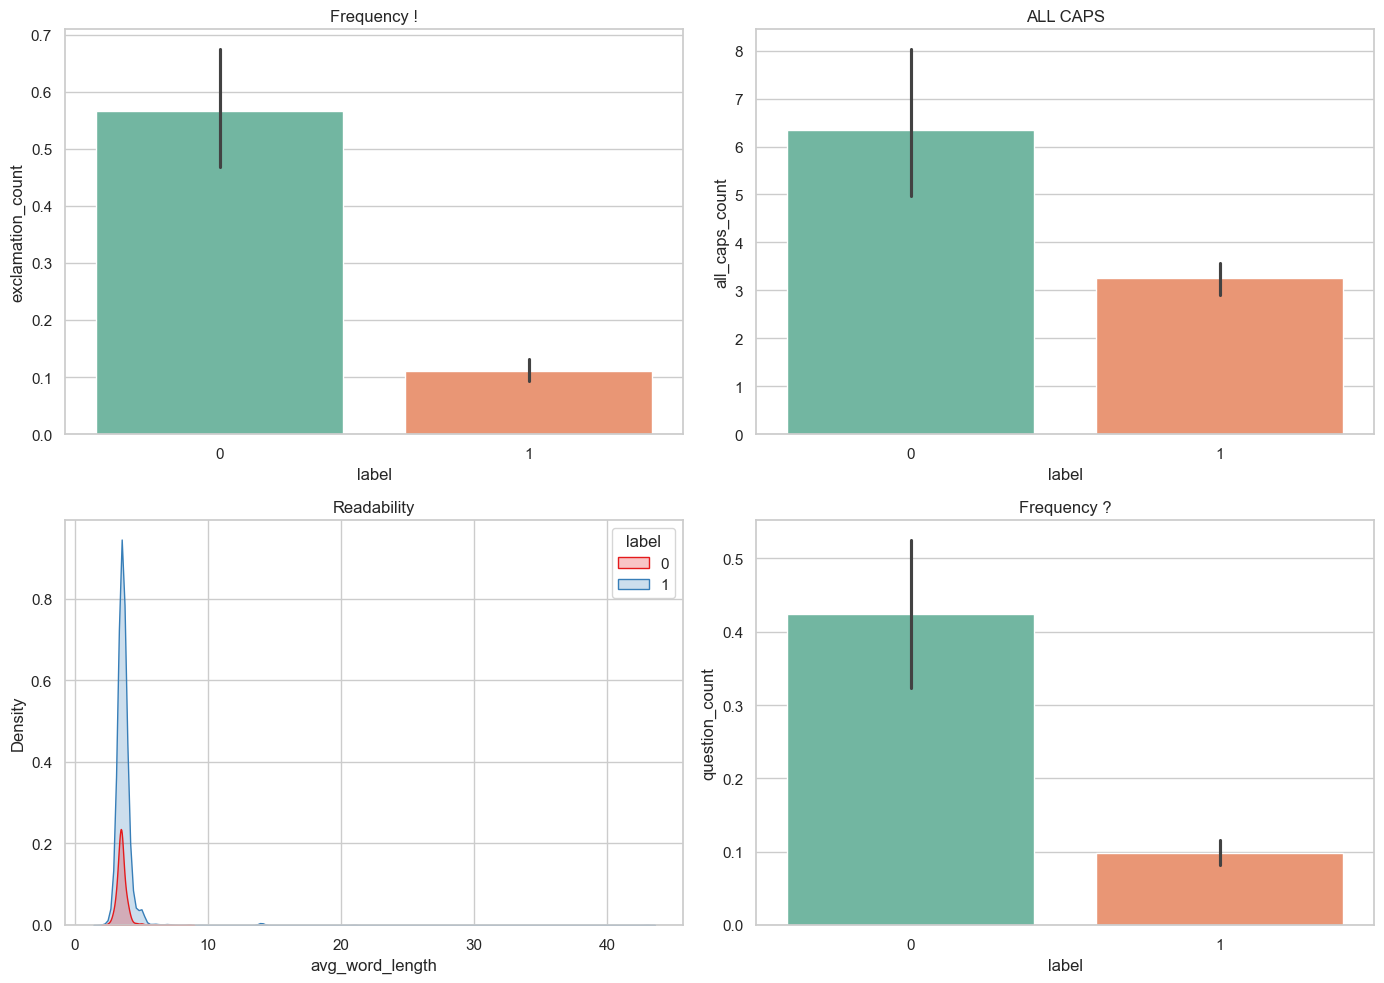

PHẦN 2: LEXICAL ANALYSIS & TTR (Sự phong phú từ vựng)
  Class  Total Words  Unique Words  TTR (Type-Token Ratio)
0  Fake        76082          7682                0.100970
1  Real       161679         13499                0.083493

PHẦN 3: TF-IDF KEYWORD DISCOVERY
--- Top 10 TF-IDF Keywords (Fake) ---
      Word      Score
858     và  36.218736
420     là  34.938872
178     có  34.674560
525  người  33.751369
379  không  29.623554
221    của  29.305452
170    các  26.625480
96     cho  26.341157
73      bị  25.293842
942     đã  24.224581

--- Top 10 TF-IDF Keywords (Real) ---
        Word       Score
855       và  131.377808
236      của  125.089783
198       có  123.659049
515    người  117.985842
189      các  113.160941
759    trong  107.152509
180  covid19  106.879627
935       đã  106.533628
422       là  101.076154
122      cho   99.844154

PHẦN 4: EMBEDDING VISUALIZATION (PCA)


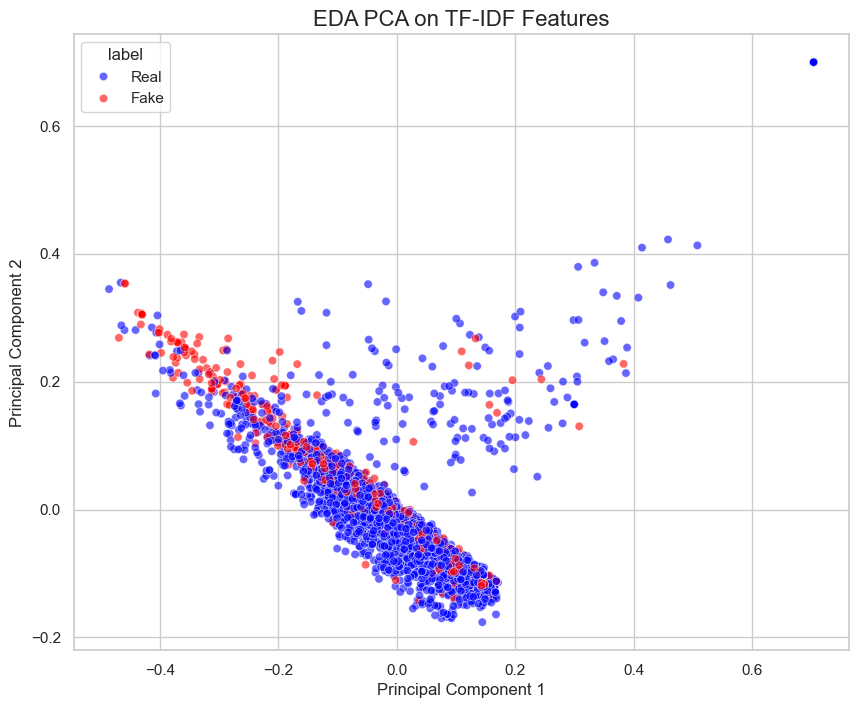

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Thiết lập style đồ thị
sns.set_theme(style="whitegrid")

# Giả sử bạn đã có DataFrame df và hàm clean_text từ các bước trước
# df = pd.read_csv('vietnamese_news.csv')

print("="*50)
print("PHẦN 1: FEATURE ENGINEERING (READABILITY & STYLE)")
print("="*50)

# 1. Punctuation Analysis (Đếm dấu chấm than, chấm hỏi)
df['exclamation_count'] = df['title'].apply(lambda x: str(x).count('!'))
df['question_count'] = df['title'].apply(lambda x: str(x).count('?'))

# 2. Capitalization Analysis (Đếm số từ IN HOA TOÀN BỘ)
def count_all_caps(text):
    words = str(text).split()
    return sum(1 for word in words if word.isupper() and len(word) > 1)

df['all_caps_count'] = df['title'].apply(count_all_caps)

# 3. Readability (Độ dài trung bình của 1 từ)
def avg_word_length(text):
    words = str(text).split()
    if not words: return 0
    return sum(len(word) for word in words) / len(words)

df['avg_word_length'] = df['title'].apply(avg_word_length)

# Trực quan hóa các Features vừa tạo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(data=df, x='label', y='exclamation_count', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Frequency !')

sns.barplot(data=df, x='label', y='all_caps_count', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('ALL CAPS')

sns.kdeplot(data=df, x='avg_word_length', hue='label', fill=True, ax=axes[1,0], palette='Set1')
axes[1,0].set_title('Readability')

sns.barplot(data=df, x='label', y='question_count', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Frequency ?')

plt.tight_layout()
plt.show()

print("="*50)
print("PHẦN 2: LEXICAL ANALYSIS & TTR (Sự phong phú từ vựng)")
print("="*50)

def calculate_ttr(corpus):
    words = ' '.join(corpus).split()
    total_words = len(words)
    unique_words = len(set(words))
    ttr = unique_words / total_words if total_words > 0 else 0
    return total_words, unique_words, ttr

# Tách corpus (Giả định nhãn 0 là Fake, 1 là Real)
fake_corpus = df[df['label'] == 0]['clean_title']
real_corpus = df[df['label'] == 1]['clean_title']

f_total, f_unique, f_ttr = calculate_ttr(fake_corpus)
r_total, r_unique, r_ttr = calculate_ttr(real_corpus)

# Tạo bảng thống kê Lexical
ttr_df = pd.DataFrame({
    'Class': ['Fake', 'Real'],
    'Total Words': [f_total, r_total],
    'Unique Words': [f_unique, r_unique],
    'TTR (Type-Token Ratio)': [f_ttr, r_ttr]
})
print(ttr_df)

print("\n" + "="*50)
print("PHẦN 3: TF-IDF KEYWORD DISCOVERY")
print("="*50)

def get_top_tfidf_words(corpus, top_n=10):
    # Khởi tạo TF-IDF (thêm stop_words nếu bạn đã tải list tiếng Việt)
    tfidf = TfidfVectorizer(max_features=1000) 
    tfidf_matrix = tfidf.fit_transform(corpus)
    
    # Tính tổng trọng số TF-IDF của từng từ
    sum_tfidf = np.asarray(tfidf_matrix.sum(axis=0)).ravel()
    
    # Ghép từ và điểm số
    tfidf_scores = pd.DataFrame({'Word': tfidf.get_feature_names_out(), 'Score': sum_tfidf})
    return tfidf_scores.sort_values(by='Score', ascending=False).head(top_n)

print("--- Top 10 TF-IDF Keywords (Fake) ---")
print(get_top_tfidf_words(fake_corpus))
print("\n--- Top 10 TF-IDF Keywords (Real) ---")
print(get_top_tfidf_words(real_corpus))

print("\n" + "="*50)
print("PHẦN 4: EMBEDDING VISUALIZATION (PCA)")
print("="*50)
# Giảm chiều dữ liệu text để vẽ lên mặt phẳng 2D
# Giúp xem hai cụm Fake và Real có tách rời nhau không

vectorizer = TfidfVectorizer(max_features=500) # Lấy 500 từ quan trọng nhất
X_tfidf = vectorizer.fit_transform(df['clean_title']).toarray()

# Dùng PCA giảm từ 500 chiều xuống 2 chiều
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tfidf)

# Tạo DataFrame để vẽ đồ thị
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['label'] = df['label'].map({0: 'Fake', 1: 'Real'}) # Đổi số sang chữ cho đồ thị đẹp

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='label', palette={'Fake': 'red', 'Real': 'blue'}, alpha=0.6)
plt.title('EDA PCA on TF-IDF Features', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [45]:
import pandas as pd
import json
import re
from underthesea import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# 1. ĐỌC DỮ LIỆU TỪ CSV VÀ SPLIT THEO JSON
# ==========================================
print("--- 1. ĐANG TẢI VÀ CHIA TẬP DỮ LIỆU ---")
# Đọc file CSV chứa nội dung bài báo
df = pd.read_csv('data.csv')

# Đọc file JSON chứa index chia tập
with open('split.json', 'r', encoding='utf-8') as f:
    splits = json.load(f)

# Tách DataFrame dựa trên danh sách index (hoặc ID) lưu trong JSON
# Lưu ý: Giả định JSON lưu danh sách row index (ví dụ: "train": [0, 1, 5, ...])
train_df = df.loc[splits['train']].copy()
val_df = df.loc[splits['val']].copy()
test_df = df.loc[splits['test']].copy()

print(f"Tổng số mẫu: {len(df)}")
print(f"Số lượng phân bổ - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ==========================================
# 2. LÀM SẠCH VÀ TÁCH TỪ (PREPROCESSING)
# ==========================================
print("\n--- 2. ĐANG LÀM SẠCH VÀ TOKENIZE TEXT ---")

def clean_and_tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text) 
    return word_tokenize(text, format="text")

# Áp dụng hàm làm sạch cho cột 'title'
train_df['clean_title'] = train_df['title'].apply(clean_and_tokenize)
val_df['clean_title'] = val_df['title'].apply(clean_and_tokenize)
test_df['clean_title'] = test_df['title'].apply(clean_and_tokenize)

# ==========================================
# 3. CHUYỂN ĐỔI VĂN BẢN THÀNH VECTOR (TF-IDF)
# ==========================================
print("\n--- 3. ĐANG VECTOR HÓA DỮ LIỆU (TF-IDF) ---")

# Khởi tạo bộ Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Fit và Transform trên Train
X_train = vectorizer.fit_transform(train_df['clean_title'])
y_train = train_df['label']

# Chỉ Transform trên Val và Test
X_val = vectorizer.transform(val_df['clean_title'])
y_val = val_df['label']

X_test = vectorizer.transform(test_df['clean_title'])
y_test = test_df['label']

# ==========================================
# 4. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH
# ==========================================
print("\n--- 4. ĐANG HUẤN LUYỆN CÁC MÔ HÌNH (TRAINING) ---")

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='linear', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results_list = []

for model_name, model in models.items():
    # Huấn luyện trên Train
    model.fit(X_train, y_train)
    
    # Đánh giá trên Test (Nếu muốn chỉnh hyperparameter, hãy đổi X_test thành X_val)
    y_pred = model.predict(X_test)
    
    # Tính toán Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Ghi nhận kết quả
    results_list.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4)
    })

# ==========================================
# 5. HIỂN THỊ KẾT QUẢ ĐÁNH GIÁ
# ==========================================
print("\n--- 5. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---")
results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

--- 1. ĐANG TẢI VÀ CHIA TẬP DỮ LIỆU ---
Tổng số mẫu: 4372
Số lượng phân bổ - Train: 3060 | Val: 656 | Test: 656

--- 2. ĐANG LÀM SẠCH VÀ TOKENIZE TEXT ---

--- 3. ĐANG VECTOR HÓA DỮ LIỆU (TF-IDF) ---

--- 4. ĐANG HUẤN LUYỆN CÁC MÔ HÌNH (TRAINING) ---

--- 5. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---
        Model  Accuracy  Precision  Recall     F1
  Naive Bayes    0.8384     0.8245  0.8384 0.7755
     Logistic    0.8567     0.8502  0.8567 0.8176
          SVM    0.8704     0.8588  0.8704 0.8490
Random Forest    0.8552     0.8409  0.8552 0.8195


In [47]:
!pip install tensorflow

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.9 MB 2.4 MB/s eta 0:02:26
   ---------------------------------------- 1.0/350.9 MB 2.5 MB/s eta 0:02:19
   ---------------------------------------- 1.6/350.9 MB 2.5 MB/s eta 0:02:18
   ---------------------------------------- 1.8/350.9 MB 2.3 MB/s eta 0:02:30
   ---------------------------------------- 2.4/350.9 MB 2.3 MB/s eta 0:02:34
   ---------------------------------------- 2.9/350.9 MB 2.5 MB/s eta 0:02:17
   ---------------------------------------- 3.1/350.9 MB 2.3 MB/s eta 0:02:31
   ---------------------------------------- 3.9/350.9 MB 2.4 MB/s eta 0:02:25
    --------------------------------------- 4.5/350.9 MB 2.5 MB/s eta 0:02:20
    --------------------------------------- 5.0/350.9 MB 2.4 MB/s eta 0:02:23
    -

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.70.0 requires protobuf!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.35.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.0 which is incompatible.
google-api-core 2.25.0rc0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.19.5, but you have protobuf 7.35.0 which is incompatible.
opentelemetry-proto 1.27.0 requires protobuf<5.0,>=3.19, but you have protobuf 7.35.0 which is incompatible.
proto-plus 1.26.1 requires protobuf<7.0.0,>=3.19.0, but you have protobuf 7.35.0 which is incompatible.
streamlit 1.24.0 requires pillow<10,>=6.2.0, but you have pillow 10.4.0 which is incom

In [50]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

print("--- GIAI ĐOẠN 3: HUẤN LUYỆN BILSTM ---")

# 1. Chuẩn bị dữ liệu chuỗi (Sequences) thay vì TF-IDF
MAX_VOCAB = 10000  # Giữ lại 10.000 từ phổ biến nhất
MAX_LEN = 100      # Cắt hoặc đệm (pad) tiêu đề về đúng 100 từ

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
# Lưu ý: Train tokenizer trên tập train để tránh data leakage
tokenizer.fit_on_texts(train_df['clean_title'])

# Chuyển chữ thành các dãy số (index) và đệm cho bằng nhau
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_title']), maxlen=MAX_LEN, padding='post')
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(val_df['clean_title']), maxlen=MAX_LEN, padding='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_title']), maxlen=MAX_LEN, padding='post')

# 2. Xây dựng kiến trúc mô hình BiLSTM
model_bilstm = Sequential([
    # Layer 1: Embedding (Học vector không gian cho từng từ)
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),
    
    # Layer 2: BiLSTM (Đọc ngữ cảnh từ trái sang phải và phải sang trái)
    Bidirectional(LSTM(64, return_sequences=False)),
    
    # Layer 3: Tránh học vẹt (Overfitting)
    Dropout(0.5),
    
    # Layer 4: Phân loại nhị phân (Fake/Real)
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Dùng sigmoid cho classification 2 lớp
])

model_bilstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_bilstm.summary()

# 3. Huấn luyện mô hình
history = model_bilstm.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=5,
    batch_size=64
)

# Đánh giá trên tập Test
test_loss, test_acc = model_bilstm.evaluate(X_test_seq, y_test)
print(f"BiLSTM Test Accuracy: {test_acc:.4f}")

--- GIAI ĐOẠN 3: HUẤN LUYỆN BILSTM ---


C:\Users\Lenovo\miniconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - accuracy: 0.8190 - loss: 0.4629 - val_accuracy: 0.8323 - val_loss: 0.4336
Epoch 2/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.8552 - loss: 0.3434 - val_accuracy: 0.8247 - val_loss: 0.4083
Epoch 3/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.9176 - loss: 0.2066 - val_accuracy: 0.8232 - val_loss: 0.5208
Epoch 4/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.9565 - loss: 0.1237 - val_accuracy: 0.8003 - val_loss: 0.6971
Epoch 5/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.9742 - loss: 0.0708 - val_accuracy: 0.7729 - val_loss: 0.7766
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8186 - loss: 0.5802
BiLSTM Test Accuracy: 0.8186


In [54]:
!pip install -U accelerate transformers packaging

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
    --------------------------------------- 0.3/10.8 MB ? eta -:--:--
   -- ------------------------------------- 0.8/10.8 MB 4.8 MB/s eta 0:00:03
   ---- ----------------------------------- 1.3/10.8 MB 3.2 MB/s eta 0:00:03
   ------ --------------------------------- 1.8/10.8 MB 2.2 MB/s eta 0:00:05
   ------- -------------------------------- 2.1/10.8 MB 2.0 MB/s eta 0:00:05
   -------- ------------------------------- 2.4/10.8 MB 2.2 MB/s eta 0:00:04
   ----------- ---------------------------- 3.1/10.8 MB 2.2 MB/s eta 0:00:04
   ------------- -------------------------- 3.7/10.8 MB 2.2 MB/s eta 0:00:04
   --------------- ------------------------ 4.2/10.8 MB 2.4 MB/s eta 0:00:03
   ----------------- ---------------------- 4.7/10.8 MB 2.3 MB/s eta 0:00:03
   ------------------- -------------------- 5.2/10.8 MB 2.3 MB/s eta 0:00:03
   --------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chromadb 1.0.7 requires pyyaml>=6.0.0, but you have pyyaml 5.3.1 which is incompatible.
gradio 3.47.1 requires websockets<12.0,>=10.0, but you have websockets 16.0 which is incompatible.
gradio-client 0.6.0 requires websockets<12.0,>=10.0, but you have websockets 16.0 which is incompatible.
langchain-core 0.3.56 requires packaging<25,>=23.2, but you have packaging 26.2 which is incompatible.
mlxtend 0.24.0 requires matplotlib>=3.10.8, but you have matplotlib 3.10.1 which is incompatible.
mlxtend 0.24.0 requires numpy>=2.3.5, but you have numpy 1.26.4 which is incompatible.
mlxtend 0.24.0 requires pandas>=2.3.3, but you have pandas 2.2.3 which is incompatible.
mlxtend 0.24.0 requires scipy>=1.16.3, but you have scipy 1.15.2 which is incompatible.
sentence-transformers 3.4.1 requires transformers<5.0.0,>=4.41.0, but

In [56]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

print("--- GIAI ĐOẠN 4: FINE-TUNE PHOBERT ---")

# 1. Tải PhoBERT Tokenizer và Model
model_name = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
# num_labels=2 vì chúng ta phân loại Fake (0) và Real (1)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 2. Chuyển đổi DataFrame sang định dạng Dataset của Hugging Face
# Giả định dữ liệu text đang nằm ở cột 'title' (bạn có thể truyền text gốc chưa qua underthesea, PhoBERT tự xử lý rất tốt)
train_dataset = Dataset.from_pandas(train_df[['title', 'label']].rename(columns={'title': 'text'}))
val_dataset = Dataset.from_pandas(val_df[['title', 'label']].rename(columns={'title': 'text'}))
test_dataset = Dataset.from_pandas(test_df[['title', 'label']].rename(columns={'title': 'text'}))

# Hàm tokenize chuẩn của PhoBERT
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# 3. Thiết lập tham số huấn luyện (Training Arguments)
training_args = TrainingArguments(
    output_dir="./phobert_fake_news",
    evaluation_strategy="epoch",  # Đánh giá sau mỗi epoch
    learning_rate=2e-5,           # Learning rate cực nhỏ để fine-tune
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,           # Transformer thường chỉ cần 3-5 epochs
    weight_decay=0.01,
    logging_dir='./logs',
)

# 4. Khởi tạo Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

# Tiến hành Fine-tune
print("Bắt đầu huấn luyện PhoBERT...")
trainer.train()

# Đánh giá trên tập Test
print("Đánh giá trên tập Test...")
predictions = trainer.predict(test_dataset)
print(predictions.metrics)

ImportError: cannot import name 'PreTrainedConfig' from 'transformers.configuration_utils' (C:\Users\Lenovo\miniconda3\Lib\site-packages\transformers\configuration_utils.py)


Đang xuất kết quả cho BiLSTM...
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step

--- KẾT QUẢ: BILSTM ---
Accuracy : 0.8186
Precision: 0.8219
Recall   : 0.8186
F1-Score : 0.8202


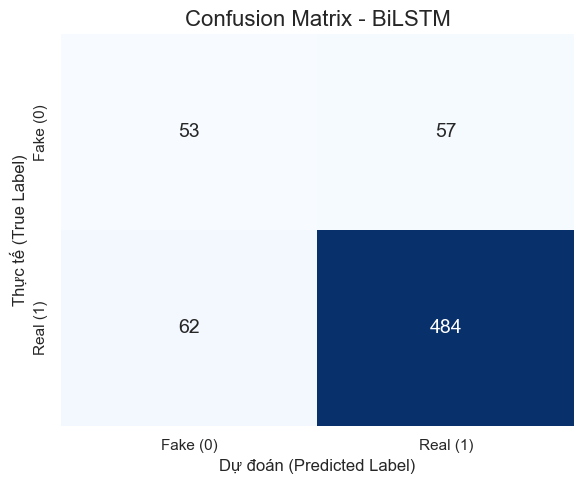


Đang xuất kết quả cho PhoBERT...


NameError: name 'trainer' is not defined

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ==========================================
# 1. HÀM TÍNH METRICS VÀ VẼ CONFUSION MATRIX
# ==========================================
def evaluate_and_plot_cm(y_true, y_pred, model_name="Model"):
    # Tính toán 4 chỉ số
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"\n--- KẾT QUẢ: {model_name.upper()} ---")
    print(f"Accuracy : {round(acc, 4)}")
    print(f"Precision: {round(prec, 4)}")
    print(f"Recall   : {round(rec, 4)}")
    print(f"F1-Score : {round(f1, 4)}")
    
    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    
    # Dùng seaborn heatmap để vẽ cho đẹp
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Fake (0)', 'Real (1)'],
                yticklabels=['Fake (0)', 'Real (1)'],
                annot_kws={"size": 14}) # Phóng to chữ số bên trong
    
    plt.title(f'Confusion Matrix - {model_name}', fontsize=16)
    plt.ylabel('Thực tế (True Label)', fontsize=12)
    plt.xlabel('Dự đoán (Predicted Label)', fontsize=12)
    plt.tight_layout()
    plt.show()

# ==========================================
# 2. ÁP DỤNG CHO BILSTM
# ==========================================
print("\nĐang xuất kết quả cho BiLSTM...")
# BiLSTM xuất ra xác suất (0.0 đến 1.0) do dùng hàm sigmoid
bilstm_probs = model_bilstm.predict(X_test_seq)

# Ép xác suất thành nhãn 0 hoặc 1 (ngưỡng 0.5)
bilstm_preds = (bilstm_probs > 0.5).astype(int).flatten()

evaluate_and_plot_cm(y_test, bilstm_preds, model_name="BiLSTM")

# ==========================================
# 3. ÁP DỤNG CHO PHOBERT (Nếu bạn chạy cả GĐ4)
# ==========================================
print("\nĐang xuất kết quả cho PhoBERT...")
# Trainer của HuggingFace trả về đối tượng PredictionOutput
phobert_output = trainer.predict(test_dataset)

# Lấy nhãn thực tế từ test_dataset
y_true_phobert = phobert_output.label_ids

# Lấy logits (điểm số thô) và dùng argmax để chọn class có điểm cao nhất
phobert_preds = np.argmax(phobert_output.predictions, axis=1)

evaluate_and_plot_cm(y_true_phobert, phobert_preds, model_name="PhoBERT")

--- 1. ĐANG TẢI VÀ CHIA TẬP DỮ LIỆU ---
Tổng số mẫu: 4372
Số lượng phân bổ - Train: 3060 | Val: 656 | Test: 656

--- 2. ĐANG LÀM SẠCH VÀ TOKENIZE TEXT ---

--- 3. ĐANG VECTOR HÓA DỮ LIỆU (TF-IDF) ---

--- 4. ĐANG HUẤN LUYỆN CÁC MÔ HÌNH (TRAINING) ---

--- 5. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---
        Model  Accuracy  Precision  Recall     F1
  Naive Bayes    0.8384     0.8245  0.8384 0.7755
     Logistic    0.8567     0.8502  0.8567 0.8176
          SVM    0.8704     0.8588  0.8704 0.8490
Random Forest    0.8552     0.8409  0.8552 0.8195

--- 6. ĐANG VẼ CONFUSION MATRIX ---


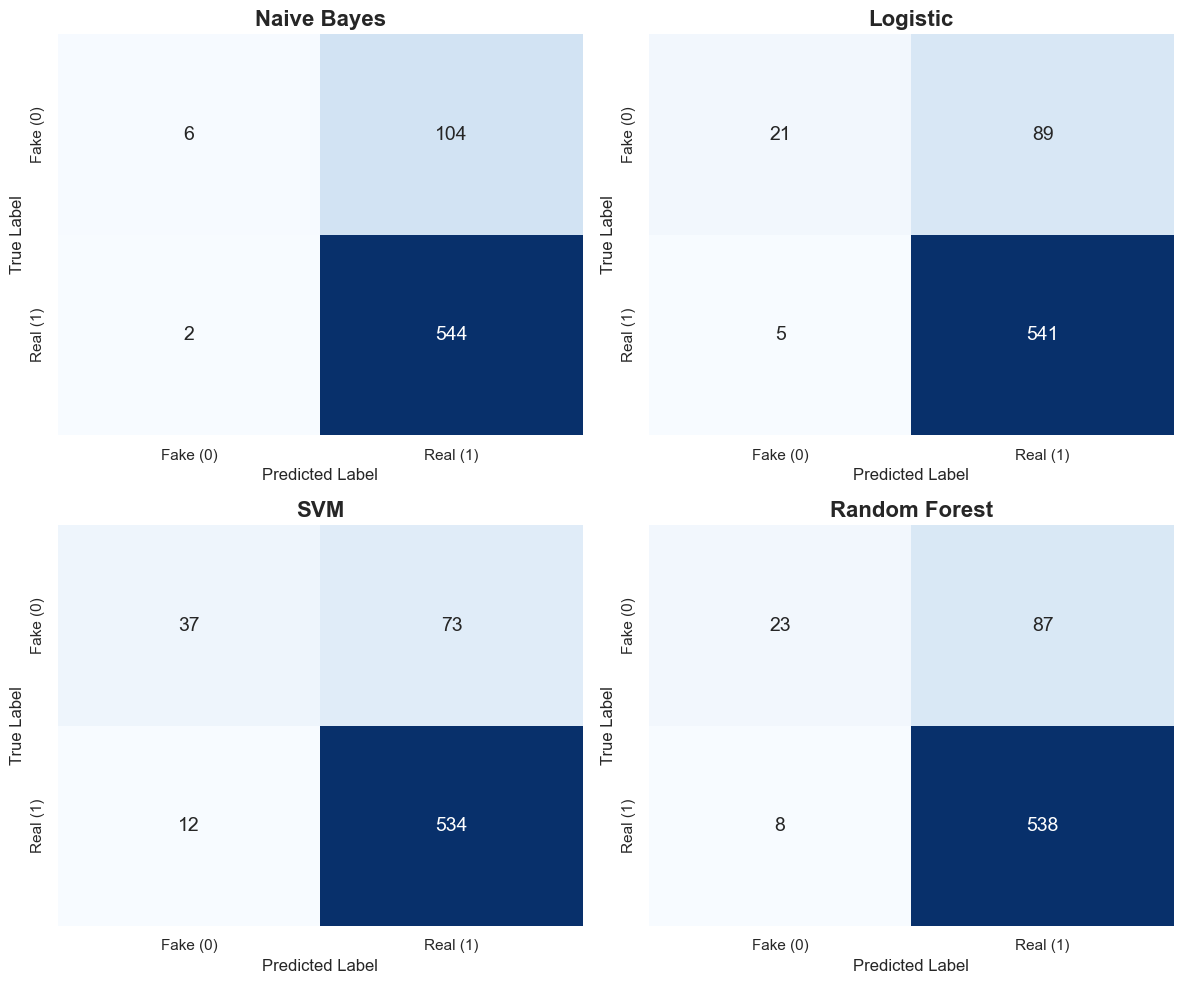

In [58]:
import pandas as pd
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns
from underthesea import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Thiết lập giao diện cho biểu đồ
sns.set_theme(style="white")

# ==========================================
# 1. ĐỌC DỮ LIỆU TỪ CSV VÀ SPLIT THEO JSON
# ==========================================
print("--- 1. ĐANG TẢI VÀ CHIA TẬP DỮ LIỆU ---")
df = pd.read_csv('data.csv')

with open('split.json', 'r', encoding='utf-8') as f:
    splits = json.load(f)

train_df = df.loc[splits['train']].copy()
val_df = df.loc[splits['val']].copy()
test_df = df.loc[splits['test']].copy()

print(f"Tổng số mẫu: {len(df)}")
print(f"Số lượng phân bổ - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ==========================================
# 2. LÀM SẠCH VÀ TÁCH TỪ (PREPROCESSING)
# ==========================================
print("\n--- 2. ĐANG LÀM SẠCH VÀ TOKENIZE TEXT ---")

def clean_and_tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text) 
    return word_tokenize(text, format="text")

train_df['clean_title'] = train_df['title'].apply(clean_and_tokenize)
val_df['clean_title'] = val_df['title'].apply(clean_and_tokenize)
test_df['clean_title'] = test_df['title'].apply(clean_and_tokenize)

# ==========================================
# 3. CHUYỂN ĐỔI VĂN BẢN THÀNH VECTOR (TF-IDF)
# ==========================================
print("\n--- 3. ĐANG VECTOR HÓA DỮ LIỆU (TF-IDF) ---")

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_df['clean_title'])
y_train = train_df['label']

X_val = vectorizer.transform(val_df['clean_title'])
y_val = val_df['label']

X_test = vectorizer.transform(test_df['clean_title'])
y_test = test_df['label']

# ==========================================
# 4. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH
# ==========================================
print("\n--- 4. ĐANG HUẤN LUYỆN CÁC MÔ HÌNH (TRAINING) ---")

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='linear', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results_list = []
cm_dict = {} # Dictionary để lưu trữ Confusion Matrix của từng mô hình

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Tính toán các chỉ số
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Tính và lưu Confusion Matrix
    cm_dict[model_name] = confusion_matrix(y_test, y_pred)
    
    results_list.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4)
    })

# ==========================================
# 5. HIỂN THỊ KẾT QUẢ VÀ CONFUSION MATRIX
# ==========================================
print("\n--- 5. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---")
results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

print("\n--- 6. ĐANG VẼ CONFUSION MATRIX ---")
# Tạo một khung ảnh (Figure) chứa 4 biểu đồ con (2 hàng, 2 cột)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # Trải phẳng mảng 2x2 thành 1D để dễ lặp qua

for i, (model_name, cm) in enumerate(cm_dict.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                annot_kws={"size": 14}) # Cỡ chữ của số liệu bên trong
    
    axes[i].set_title(f'{model_name}', fontsize=16, fontweight='bold')
    
    # Đặt tên trục (Giả định nhãn 0 là Fake, 1 là Real. Bạn có thể sửa lại nếu data của bạn khác)
    axes[i].set_xticklabels(['Fake (0)', 'Real (1)'])
    axes[i].set_yticklabels(['Fake (0)', 'Real (1)'])
    axes[i].set_ylabel('True Label', fontsize=12)
    axes[i].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()